# Data-Driven Heston Bounds — Independent Walkthrough

A standalone, step-by-step reimplementation of how the calibration's **initial guess
and search bounds** are derived from the shape of the NVDA implied-volatility surface.

**Nothing here imports from `calibration/data_driven_bounds.py`** — every step is
written out inline so you can inspect and tweak each piece. We only reuse the data
*fetch* and *filter* helpers, and the Black-Scholes IV inverter (a generic building
block, not part of the bounds logic).

The methodology is kept **identical** to the production code; this is just an
independent copy you can play with.

> **This notebook currently covers only `v0` (initial variance).**
> The other parameters (theta, sigma, rho, kappa) will be added in later sections.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Allowed helpers: data fetch/filter + generic BS implied-vol inverter.
# (We do NOT import anything from calibration/data_driven_bounds.py.)
from data.market_data import get_all_options
from services.market_service import filter_chain_with_stats
from config.market_config import get_ois_curve, interpolate_rate
from calibration.implied_vol import implied_volatility

pd.set_option('display.float_format', '{:.4f}'.format)
pd.set_option('display.width', 120)
plt.rcParams['figure.dpi'] = 110

## 0 — Fetch and filter the NVDA chain

We pull the live chain and apply the same liquidity filters used elsewhere, so the
universe we read the surface from is the same one calibration sees.

In [2]:
TICKER = 'NVDA'

rate_curve = get_ois_curve(force_refresh=True)
raw_df = get_all_options(TICKER)
SPOT = raw_df['spot'].iloc[0]

filtered_df, _stats = filter_chain_with_stats(
    raw_df,
    spread_limit=0.05,
    rate_curve=rate_curve,
    min_volume=50,
    min_open_interest=200,
    moneyness_lo=0.8,
    moneyness_hi=1.2,
)
Q = float(filtered_df['q'].iloc[0])
print(f'{TICKER}: spot ${SPOT:.2f}, q={Q*100:.3f}%')
print(f'Filtered contracts: {len(filtered_df)}  across {filtered_df["maturity"].nunique()} expiries')

NVDA: spot $195.15, q=0.143%
Filtered contracts: 376  across 21 expiries


## 1 — Compute market IV and log-moneyness

For every contract we invert the Black-Scholes price for its implied vol (using the
contract's own maturity-matched rate `r` and dividend yield `q`), and define
log-moneyness `k = log(K / S)`.

In [3]:
df = filtered_df.copy()

df['log_moneyness'] = np.log(df['strike'] / df['spot'])

df['market_iv'] = df.apply(
    lambda row: implied_volatility(
        row['mid_price'], row['spot'], row['strike'],
        float(row['r']), row['T'], row['type'], float(row['q']),
    ),
    axis=1,
)

# Keep only valid-IV rows (matches the production "working set")
iv_df = df[df['market_iv'].notna() & (df['market_iv'] > 0.01)].copy()
print(f'Valid-IV contracts: {len(iv_df)} / {len(df)}')
iv_df[['type', 'maturity', 'T', 'strike', 'log_moneyness', 'mid_price', 'market_iv']].head()

Valid-IV contracts: 376 / 376


,type,maturity,T,strike,log_moneyness,mid_price,market_iv
0,call,2026-06-26,0.0015,175.0000,-0.1090,20.2000,1.2841
1,put,2026-06-26,0.0015,185.0000,-0.0534,0.2050,0.9414
2,put,2026-06-26,0.0015,187.5000,-0.0400,0.4050,0.9071
3,call,2026-06-26,0.0015,190.0000,-0.0267,5.4000,0.5847
4,put,2026-06-26,0.0015,190.0000,-0.0267,0.7200,0.8519


## 2 — Knobs

These are the exact constants used by the production routine. Change them here to see
how `v0` responds.

In [4]:
ATM_THRESHOLD = 0.10   # |log(K/S)| window for picking the ATM IV (intercept fit)
MIN_CONTRACTS = 5      # a maturity must have >= this many valid-IV rows to count as "liquid"
FIT_DEGREE    = 2      # smile is fit as a quadratic in k:  iv ~ a + b k + c k^2
V0_LO_MULT    = 0.7    # lower bound = V0_LO_MULT * v0*
V0_HI_MULT    = 1.3    # upper bound = V0_HI_MULT * v0*

## 3 — Select liquid maturities, pick the shortest

`v0` (the *instantaneous* variance) is read from the **shortest liquid maturity** —
the slice closest to "now", so its ATM variance is the best proxy for `v_0`.

A maturity counts as liquid if it has at least `MIN_CONTRACTS` valid-IV rows.

In [5]:
counts = iv_df.groupby('T').size()
liquid_T = sorted(counts[counts >= MIN_CONTRACTS].index.tolist())

print('Valid-IV contracts per maturity (liquid = >= %d):' % MIN_CONTRACTS)
for T in sorted(counts.index):
    mark = '  <- liquid' if T in liquid_T else ''
    print(f'  T={T:6.4f}  n={int(counts[T]):3d}{mark}')

assert len(liquid_T) >= 1, 'No liquid maturities found.'
T_short = liquid_T[0]
print(f'\nShortest liquid maturity  T_short = {T_short:.4f}  '
      f'({iv_df[iv_df.T == T_short]["maturity"].iloc[0]})')
short_slice = iv_df[iv_df['T'] == T_short].copy()

Valid-IV contracts per maturity (liquid = >= 5):
  T=0.0015  n= 19  <- liquid
  T=0.0097  n= 14  <- liquid
  T=0.0152  n= 11  <- liquid
  T=0.0179  n= 29  <- liquid
  T=0.0398  n= 18  <- liquid
  T=0.0590  n= 26  <- liquid
  T=0.0782  n= 20  <- liquid
  T=0.0973  n= 17  <- liquid
  T=0.1549  n= 27  <- liquid
  T=0.2316  n= 25  <- liquid
  T=0.3083  n= 21  <- liquid
  T=0.4042  n= 19  <- liquid
  T=0.4809  n= 34  <- liquid
  T=0.5576  n= 21  <- liquid
  T=0.7302  n= 20  <- liquid
  T=0.9768  n= 18  <- liquid
  T=1.2289  n=  7  <- liquid
  T=1.4782  n=  6  <- liquid
  T=1.5741  n=  8  <- liquid
  T=1.9768  n=  4
  T=2.4754  n= 12  <- liquid

Shortest liquid maturity  T_short = 0.0015  (nan)


## 4 — ATM IV at the shortest maturity  *(the core step for v0)*

The ATM implied vol of the shortest slice is estimated by fitting a quadratic smile
`iv ≈ a + b·k + c·k²` over the near-ATM window `|k| < ATM_THRESHOLD`, then reading
the **intercept** `a` (the value at `k = 0`). Fallbacks:

- if there are too few near-ATM points to fit → use the nearest-to-ATM contract's IV,
- if the polynomial fit fails → use the median IV of the window,
- finally clip into `[0.01, 5.0]`.

Below are inline copies of the two helpers (reimplemented, not imported).

In [6]:
def fit_smile(k, iv, degree=2):
    """Fit iv ~ a + b k + c k^2 by least squares. Returns [a, b, c] (padded) or None."""
    k = np.asarray(k, float)
    iv = np.asarray(iv, float)
    mask = np.isfinite(k) & np.isfinite(iv) & (iv > 0)
    k, iv = k[mask], iv[mask]
    n = len(k)
    if n < 2:
        return None
    deg = min(degree, n - 1)
    try:
        poly = np.polyfit(k, iv, deg=deg)   # highest-degree first
        coeffs = poly[::-1]                  # -> [a, b, c, ...]
        while len(coeffs) < 3:
            coeffs = np.append(coeffs, 0.0)
        return coeffs
    except Exception:
        return None


def atm_iv_from_slice(slice_df, atm_threshold):
    """ATM IV (k=0) for one maturity slice: quadratic-fit intercept, with fallbacks."""
    sub = slice_df[
        (slice_df['log_moneyness'].abs() < atm_threshold)
        & slice_df['market_iv'].notna()
        & (slice_df['market_iv'] > 0.01)
    ]
    if sub.empty:
        idx = slice_df['log_moneyness'].abs().idxmin()
        val = slice_df.loc[idx, 'market_iv']
        return float(val) if not pd.isna(val) else np.nan

    k = sub['log_moneyness'].values
    iv = sub['market_iv'].values
    coeffs = fit_smile(k, iv, degree=min(FIT_DEGREE, len(sub) - 1))
    if coeffs is None:
        return float(np.nanmedian(iv))
    return float(np.clip(coeffs[0], 0.01, 5.0))

In [7]:
# Apply to the shortest slice and expose the intermediate fit
near_atm = short_slice[
    (short_slice['log_moneyness'].abs() < ATM_THRESHOLD)
    & short_slice['market_iv'].notna()
    & (short_slice['market_iv'] > 0.01)
]
coeffs = fit_smile(near_atm['log_moneyness'].values,
                   near_atm['market_iv'].values,
                   degree=min(FIT_DEGREE, len(near_atm) - 1)) if len(near_atm) >= 2 else None

sigma_atm_short = atm_iv_from_slice(short_slice, ATM_THRESHOLD)

print(f'Near-ATM contracts in window |k| < {ATM_THRESHOLD}: {len(near_atm)}')
if coeffs is not None:
    a, b, c = coeffs[:3]
    print(f'Quadratic smile fit:  iv ~ {a:.4f} + {b:.4f} k + {c:.4f} k^2')
    print(f'  intercept a (ATM IV at k=0) = {a:.4f}')
print(f'\nsigma_atm_short (clipped to [0.01, 5]) = {sigma_atm_short:.4f}  '
      f'= {sigma_atm_short*100:.2f}%')

Near-ATM contracts in window |k| < 0.1: 17
Quadratic smile fit:  iv ~ 0.7529 + 1.9692 k + 95.7591 k^2
  intercept a (ATM IV at k=0) = 0.7529

sigma_atm_short (clipped to [0.01, 5]) = 0.7529  = 75.29%


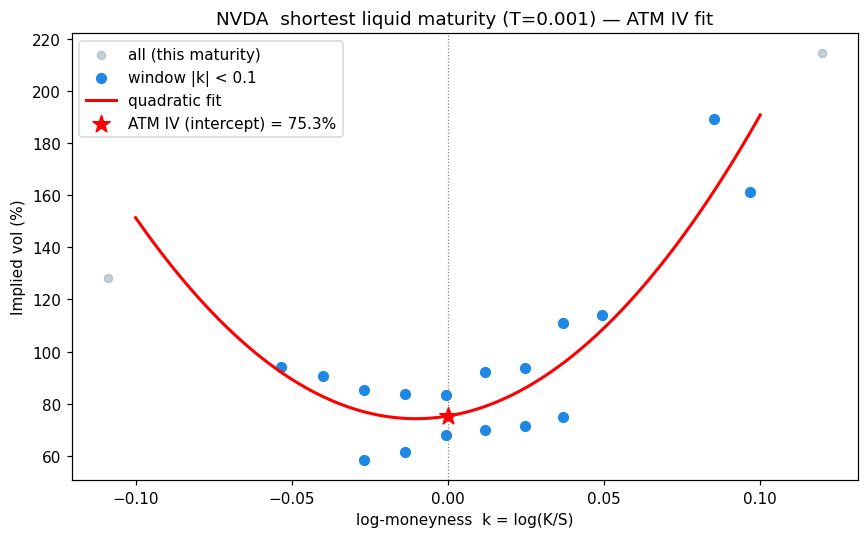

In [8]:
# Visualize the shortest-maturity smile and the ATM intercept
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(short_slice['log_moneyness'], short_slice['market_iv'] * 100,
           s=28, alpha=0.5, color='#90A4AE', label='all (this maturity)')
ax.scatter(near_atm['log_moneyness'], near_atm['market_iv'] * 100,
           s=40, color='#1E88E5', label=f'window |k| < {ATM_THRESHOLD}')

if coeffs is not None:
    kk = np.linspace(-ATM_THRESHOLD, ATM_THRESHOLD, 100)
    fit_iv = (coeffs[0] + coeffs[1] * kk + coeffs[2] * kk ** 2) * 100
    ax.plot(kk, fit_iv, 'r-', lw=2, label='quadratic fit')
ax.scatter([0], [sigma_atm_short * 100], s=140, marker='*', color='red',
           zorder=5, label=f'ATM IV (intercept) = {sigma_atm_short*100:.1f}%')

ax.axvline(0, color='gray', lw=0.8, ls=':')
ax.set_xlabel('log-moneyness  k = log(K/S)')
ax.set_ylabel('Implied vol (%)')
ax.set_title(f'{TICKER}  shortest liquid maturity (T={T_short:.3f}) — ATM IV fit')
ax.legend()
plt.tight_layout(); plt.show()

## 5 — v0 and its bounds

`v0` is the ATM **variance** at the shortest maturity, with a ±30% box:

    v0*  = sigma_atm_short ** 2
    v0_lo = max(V0_LO_MULT * v0*, 1e-4)
    v0_hi = min(V0_HI_MULT * v0*, 2.0)

In [9]:
v0_star = sigma_atm_short ** 2
v0_lo = max(V0_LO_MULT * v0_star, 1e-4)
v0_hi = min(V0_HI_MULT * v0_star, 2.0)

print('Initial variance v0')
print('-' * 40)
print(f'  sigma_atm_short : {sigma_atm_short:.4f}   ({sigma_atm_short*100:.2f}% vol)')
print(f'  v0*  (guess)    : {v0_star:.4f}   (= sigma^2)')
print(f'  v0_lo           : {v0_lo:.4f}   ({V0_LO_MULT:.0%} of v0*)')
print(f'  v0_hi           : {v0_hi:.4f}   ({V0_HI_MULT:.0%} of v0*)')
print(f'  implied vol band: {np.sqrt(v0_lo)*100:.1f}%  -  {np.sqrt(v0_hi)*100:.1f}%')

Initial variance v0
----------------------------------------
  sigma_atm_short : 0.7529   (75.29% vol)
  v0*  (guess)    : 0.5668   (= sigma^2)
  v0_lo           : 0.3968   (70% of v0*)
  v0_hi           : 0.7369   (130% of v0*)
  implied vol band: 63.0%  -  85.8%


## Exploration — is the shortest maturity representative?

`v0` is taken from a *single* slice (the shortest). It's worth eyeballing the ATM IV
across **all** liquid maturities to see how much `v0` would move if a different short
slice were chosen, and whether the very-shortest expiry is noisy (it often is).

/var/folders/40/s4f2hrxs7sd19qb8q2_3j3fm0000gn/T/ipykernel_35115/240746033.py:12: RankWarning: Polyfit may be poorly conditioned
  poly = np.polyfit(k, iv, deg=deg)   # highest-degree first
/var/folders/40/s4f2hrxs7sd19qb8q2_3j3fm0000gn/T/ipykernel_35115/240746033.py:12: RankWarning: Polyfit may be poorly conditioned
  poly = np.polyfit(k, iv, deg=deg)   # highest-degree first


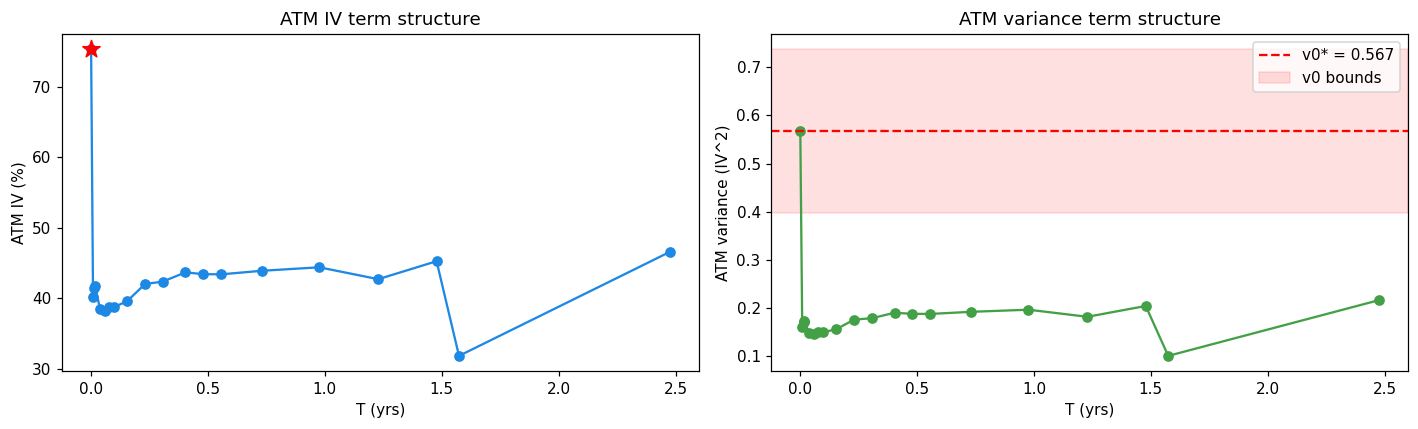

     T  atm_iv  atm_var
0.0015  0.7529   0.5668
0.0097  0.4013   0.1611
0.0152  0.4149   0.1721
0.0179  0.4178   0.1746
0.0398  0.3846   0.1479
0.0590  0.3824   0.1462
0.0782  0.3873   0.1500
0.0973  0.3872   0.1499
0.1549  0.3957   0.1566
0.2316  0.4201   0.1765
0.3083  0.4237   0.1795
0.4042  0.4367   0.1907
0.4809  0.4342   0.1885
0.5576  0.4339   0.1883
0.7302  0.4389   0.1927
0.9768  0.4439   0.1971
1.2289  0.4270   0.1824
1.4782  0.4525   0.2048
1.5741  0.3182   0.1013
2.4754  0.4658   0.2169


In [10]:
atm_term = pd.DataFrame({
    'T': liquid_T,
    'atm_iv': [atm_iv_from_slice(iv_df[iv_df['T'] == T], ATM_THRESHOLD) for T in liquid_T],
})
atm_term['atm_var'] = atm_term['atm_iv'] ** 2

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(atm_term['T'], atm_term['atm_iv'] * 100, 'o-', color='#1E88E5')
axes[0].scatter([T_short], [sigma_atm_short * 100], s=140, marker='*', color='red', zorder=5)
axes[0].set_xlabel('T (yrs)'); axes[0].set_ylabel('ATM IV (%)')
axes[0].set_title('ATM IV term structure')

axes[1].plot(atm_term['T'], atm_term['atm_var'], 'o-', color='#43A047')
axes[1].axhline(v0_star, color='red', ls='--', label=f'v0* = {v0_star:.3f}')
axes[1].axhspan(v0_lo, v0_hi, color='red', alpha=0.12, label='v0 bounds')
axes[1].set_xlabel('T (yrs)'); axes[1].set_ylabel('ATM variance (IV^2)')
axes[1].set_title('ATM variance term structure'); axes[1].legend()
plt.tight_layout(); plt.show()

print(atm_term.to_string(index=False))

### Notes / things to scrutinize

- **v0 rests entirely on one slice** (the shortest liquid maturity). The shortest
  listed expiry is frequently the noisiest (microstructure, low T). If it looks like
  an outlier in the plot above, `v0` inherits that noise.
- The **±30% box** is symmetric in *variance*, i.e. asymmetric in vol. It is also
  arbitrary — not derived from any uncertainty estimate of the ATM fit.
- The ATM IV is the **quadratic intercept**, which can differ from the single
  nearest-ATM quote when the smile is steep; compare the red star to the raw points.
- Knobs to play with: `ATM_THRESHOLD` (window width), `MIN_CONTRACTS` (which
  maturity becomes `T_short`), `V0_LO_MULT` / `V0_HI_MULT` (box width).